In [3]:
!pip install lxml html5lib requests pycairo cairocffi yfinance

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import requests
import io
from scipy.stats import linregress, chi2

# ==========================================
# 1. FUNCIONES CORE (Física Estadística)
# ==========================================
def calc_fourier_y_xi(spins_1d_array, L):
    spins_2d = spins_1d_array.reshape(-1, L, L)
    V = L * L
    M = np.sum(spins_2d, axis=(1, 2))
    M2 = (M / V)**2
    
    k_vec = 2 * np.pi * np.arange(L) / L
    cos_k = np.cos(k_vec)
    sin_k = np.sin(k_vec)
    
    sum_y = np.sum(spins_2d, axis=1) 
    sum_x = np.sum(spins_2d, axis=2) 
    
    mod_X2 = np.dot(sum_y, cos_k)**2 + np.dot(sum_y, sin_k)**2
    mod_Y2 = np.dot(sum_x, cos_k)**2 + np.dot(sum_x, sin_k)**2
    
    F10 = 0.5 * (mod_X2 + mod_Y2) / (V * V)
    return M2, F10

def formula_xi(m2, f10, L):
    ratio = m2 / f10 - 1.0
    ratio[ratio < 0] = 0 
    return np.sqrt(ratio) / (2.0 * np.sin(np.pi / L))

# ==========================================
# 2. DESCARGA DEL S&P 1500 Y TOPOLOGÍA REAL
# ==========================================
print("Extrayendo S&P 1500 oficial desde Wikipedia con Sectores GICS...")
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}

def extraer_indice_wiki(url):
    html = requests.get(url, headers=headers).text
    df = pd.read_html(io.StringIO(html))[0]
    col_ticker = 'Symbol' if 'Symbol' in df.columns else 'Ticker'
    col_sector = 'GICS Sector' if 'GICS Sector' in df.columns else 'Sector'
    return df[[col_ticker, col_sector]].rename(columns={col_ticker: 'Symbol', col_sector: 'Sector'})

sp500 = extraer_indice_wiki('https://en.wikipedia.org/wiki/List_of_S%26P_500_companies')
sp400 = extraer_indice_wiki('https://en.wikipedia.org/wiki/List_of_S%26P_400_companies')
sp600 = extraer_indice_wiki('https://en.wikipedia.org/wiki/List_of_S%26P_600_companies')

df_sp1500 = pd.concat([sp500, sp400, sp600], ignore_index=True).drop_duplicates(subset=['Symbol'])
df_sp1500 = df_sp1500.sort_values(by='Sector')
all_tickers = [str(t).replace('.', '-') for t in df_sp1500['Symbol'].tolist()]

print(f"Total empresas encontradas: {len(all_tickers)}. Descargando años 2017-2018...")
data = yf.download(all_tickers, start="2017-01-01", end="2018-12-31", progress=False)
if isinstance(data.columns, pd.MultiIndex): data = data['Close']

tickers_descargados = data.columns.tolist()
tickers_ordenados = [t for t in all_tickers if t in tickers_descargados]
data = data[tickers_ordenados]

# Tratamiento riguroso de datos faltantes
data_limpia = data.ffill().bfill()
returns_real_base = data_limpia.pct_change().dropna(how='all').dropna(axis=1)

N_requerido = 1024
empresas_validas = returns_real_base.shape[1]
print(f"Han sobrevivido {empresas_validas} empresas reales y únicas de todo el S&P 1500.")

if empresas_validas >= N_requerido:
    returns_real_base = returns_real_base.iloc[:, :N_requerido]
    print(f"Éxito: Matriz recortada a {returns_real_base.shape[1]} empresas puras.")
else:
    raise ValueError(f"CRÍTICO: Solo sobrevivieron {empresas_validas} empresas reales. Se exigen {N_requerido} para la topología de red L=32. \nSolución obligatoria: Modifique las fechas de descarga a un periodo aún más reciente o amplíe el índice base.")



Extrayendo S&P 1500 oficial desde Wikipedia con Sectores GICS...
Total empresas encontradas: 1500. Descargando años 2017-2018...


$ULS: possibly delisted; no price data found  (1d 2017-01-01 -> 2018-12-31) (Yahoo error = "Data doesn't exist for startDate = 1483246800, endDate = 1546232400")
$VIR: possibly delisted; no price data found  (1d 2017-01-01 -> 2018-12-31) (Yahoo error = "Data doesn't exist for startDate = 1483246800, endDate = 1546232400")
$VLTO: possibly delisted; no price data found  (1d 2017-01-01 -> 2018-12-31) (Yahoo error = "Data doesn't exist for startDate = 1483246800, endDate = 1546232400")
$ASO: possibly delisted; no price data found  (1d 2017-01-01 -> 2018-12-31) (Yahoo error = "Data doesn't exist for startDate = 1483246800, endDate = 1546232400")
$AHR: possibly delisted; no price data found  (1d 2017-01-01 -> 2018-12-31) (Yahoo error = "Data doesn't exist for startDate = 1483246800, endDate = 1546232400")
$KVUE: possibly delisted; no price data found  (1d 2017-01-01 -> 2018-12-31) (Yahoo error = "Data doesn't exist for startDate = 1483246800, endDate = 1546232400")
$PAYO: possibly delisted; 

Han sobrevivido 1365 empresas reales y únicas de todo el S&P 1500.
Éxito: Matriz recortada a 1024 empresas puras.


Iniciando procesamiento global incondicional para T=500 pasos temporales...
Calculando retículo L=8 (N=64)...
Calculando retículo L=16 (N=256)...
Calculando retículo L=32 (N=1024)...

--- RESULTADOS DE REGRESIÓN OLS ---
Magnetización: Pendiente = 0.0117 \pm 0.0068
Susceptibilidad: Pendiente = 2.0345 \pm 0.0302
Calor Específico: Pendiente = 1.7956 \pm 0.1236


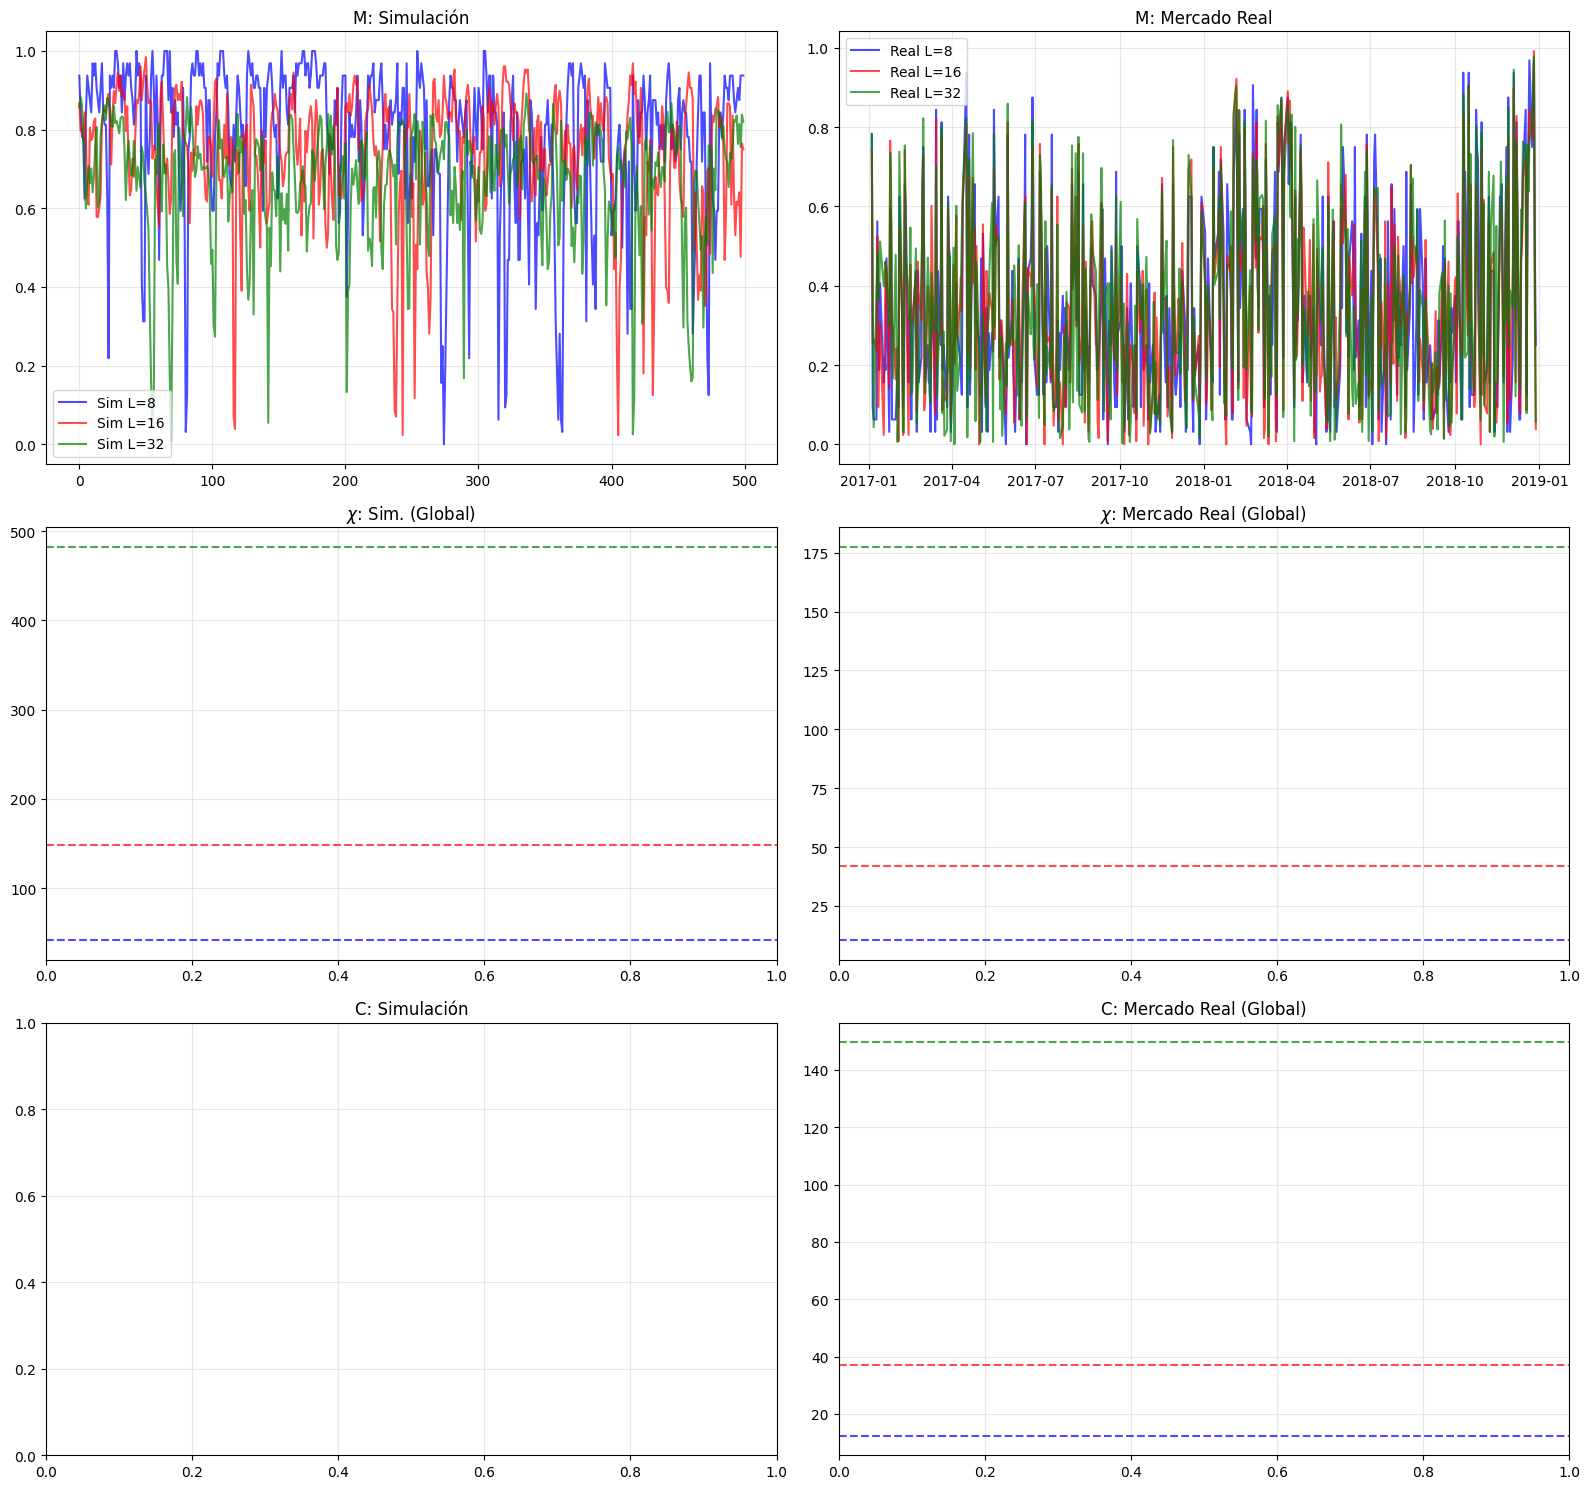


EXPONENTE       | VALOR EMPÍRICO     | ONSAGER (2D)    | C. MEDIO (MF)  
nu (Long. Corr) |   0.519 ± 0.017   |  1.00 ( 27.9σ) |  0.50 (  1.1σ)
alpha (Calor)   |   0.932 ± 0.071   |  0.00 ( 13.1σ) |  0.00 ( 13.1σ)
beta (Mag)      |   0.006 ± 0.004   |  0.12 ( 33.8σ) |  0.50 (140.3σ)
gamma (Susc)    |   1.056 ± 0.038   |  1.75 ( 18.1σ) |  1.00 (  1.5σ)
delta (Isot)    | 175.474 ± 101.335 | 15.00 (  1.6σ) |  3.00 (  1.7σ)
eta (Anom)      |  -0.034 ± 0.030   |  0.25 (  9.4σ) |  0.00 (  1.1σ)

Generando reportes vectoriales FSS...
Exportado: FSS_Magnetizacion.pdf
Exportado: FSS_Susceptibilidad.pdf
Exportado: FSS_Calor_Especifico.pdf
Exportado: FSS_Longitud_Correlacion.pdf

Proceso de exportación finalizado.


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Definición del diccionario de colores faltante
colores = {8: 'blue', 16: 'red', 32: 'green'}

# 1. PARÁMETROS Y CONTENEDORES
tamaños_L = [8, 16, 32]
# Eliminada la variable 'vent' (ventana temporal)
K_c = 0.5 * np.log(1 + np.sqrt(2))
p_bond = 1.0 - np.exp(-2.0 * K_c)

resultados_real = {}
resultados_sim = {}

# Longitud temporal
num_pasos_real = returns_real_base.shape[0]
fechas_real = returns_real_base.index

print(f"Iniciando procesamiento global incondicional para T={num_pasos_real} pasos temporales...")

# 2. CÁLCULO: REAL VS SIMULACIÓN
for L in tamaños_L:
    N = L * L
    print(f"Calculando retículo L={L} (N={N})...")
    
    # --- A) DATOS REALES ---
    ret_real_L = returns_real_base.iloc[:, :N].copy()
    spins_real = np.sign(ret_real_L).replace(0, 1).values
    
    # Topología
    edges_list = []
    for i in range(N):
        r, c = i // L, i % L
        vecinos = [((r-1)%L)*L+c, ((r+1)%L)*L+c, r*L+(c-1)%L, r*L+(c+1)%L]
        for v in vecinos:
            if i < v: edges_list.append((i, v))
    edges = np.array(edges_list)
    
    # Microestados instantáneos
    interacciones = spins_real[:, edges[:, 0]] * spins_real[:, edges[:, 1]]
    E_t_real = -np.sum(interacciones, axis=1) / float(N)
    M_t_real_raw = np.mean(spins_real, axis=1)
    
    # Cálculo termodinámico estático global (Varianza incondicional, ddof=1 para estimador insesgado)
    resultados_real[L] = {
        'M_t': np.abs(M_t_real_raw),                # Serie temporal conservada para el plot de M
        'M_global': np.mean(np.abs(M_t_real_raw)),  # Parámetro de orden global
        'Chi_global': N * np.var(M_t_real_raw, ddof=1), # Susceptibilidad estática
        'C_global': N * np.var(E_t_real, ddof=1)        # Calor específico global
    }

    # --- B) SIMULACIÓN MONTE CARLO ---
    estado = np.random.choice([-1, 1], size=N)
    # Termalización
    for _ in range(200):
        estado = swendsen_wang_fast(estado, p_bond, edges, N)
        
    m_t_sim = []
    spins_history_sim = []
    
    for _ in range(num_pasos_real):
        estado = swendsen_wang_fast(estado, p_bond, edges, N)
        m_t_sim.append(np.abs(np.mean(estado)))
        spins_history_sim.append(estado.copy())
    
    m_t_sim = np.array(m_t_sim)
    spins_history_sim = np.array(spins_history_sim)
    
    M_t_sim_raw = np.mean(spins_history_sim, axis=1)
    
    resultados_sim[L] = {
        'M_t': m_t_sim,
        'M_global': np.mean(m_t_sim),
        'Chi_global': N * np.var(M_t_sim_raw, ddof=1)
    }

# 3. REGRESIÓN OLS PARA FINITE SIZE SCALING (FSS)
L_vals = np.array(tamaños_L)
log_L = np.log(L_vals)

# Extracción directa de los escalares globales (ya no se buscan máximos locales)
M_mean = np.array([resultados_real[L]['M_global'] for L in tamaños_L])
Chi_max = np.array([resultados_real[L]['Chi_global'] for L in tamaños_L])
C_max = np.array([resultados_real[L]['C_global'] for L in tamaños_L])

log_M, log_Chi, log_C = np.log(M_mean), np.log(Chi_max), np.log(C_max)

def realizar_ajuste(log_x, log_y, nombre_observable):
    res = linregress(log_x, log_y)
    print(rf"{nombre_observable}: Pendiente = {res.slope:.4f} \pm {res.stderr:.4f}")
    return res.intercept, res.slope, res.intercept + res.slope * log_x, res.stderr

print("\n--- RESULTADOS DE REGRESIÓN OLS ---")
int_M, slp_M, fit_M, stderr_M = realizar_ajuste(log_L, log_M, "Magnetización")
int_Chi, slp_Chi, fit_Chi, stderr_Chi = realizar_ajuste(log_L, log_Chi, "Susceptibilidad")
int_C, slp_C, fit_C, stderr_C = realizar_ajuste(log_L, log_C, "Calor Específico")

# 4. PLOTS DE EVOLUCIÓN TEMPORAL
fig, axs = plt.subplots(3, 2, figsize=(16, 15))
for L in tamaños_L:
    col = colores[L]
    
    # Magnetización (instantánea, mantiene sentido temporal)
    axs[0, 0].plot(resultados_sim[L]['M_t'], color=col, alpha=0.7, label=f'Sim L={L}')
    axs[0, 1].plot(fechas_real, resultados_real[L]['M_t'], color=col, alpha=0.7, label=f'Real L={L}')
    
    # Susceptibilidad (ahora es un escalar global, se representa como línea horizontal)
    axs[1, 0].axhline(y=resultados_sim[L]['Chi_global'], color=col, linestyle='--', alpha=0.7)
    axs[1, 1].axhline(y=resultados_real[L]['Chi_global'], color=col, linestyle='--', alpha=0.7)
    
    # Calor Específico (escalar global)
    axs[2, 1].axhline(y=resultados_real[L]['C_global'], color=col, linestyle='--', alpha=0.7)

titles = [["M: Simulación", "M: Mercado Real"], 
          [r"$\chi$: Sim. (Global)", r"$\chi$: Mercado Real (Global)"], 
          ["C: Simulación", "C: Mercado Real (Global)"]]

for i in range(3):
    for j in range(2):
        axs[i, j].set_title(titles[i][j])
        axs[i, j].grid(True, alpha=0.3)
        if i == 0: axs[i, j].legend()
plt.tight_layout()
plt.show()

# 5. CÁLCULO DE EXPONENTES Y PROPAGACIÓN DE ERRORES
# b_x = x/nu (Pendientes OLS)
b_M, b_Chi, b_C = abs(slp_M), slp_Chi, slp_C

# Cálculo de nu por hiperscala
nu_emp = 2.0 / (b_C + 2*b_M + b_Chi)
sigma_nu = (nu_emp**2 / 2.0) * np.sqrt(stderr_C**2 + 4*stderr_M**2 + stderr_Chi**2)

def calc_exp(b, sb, nu, snu):
    val = b * nu
    err = val * np.sqrt((sb/b)**2 + (snu/nu)**2)
    return val, err

alpha_emp, sigma_alpha = calc_exp(b_C, stderr_C, nu_emp, sigma_nu)
beta_emp, sigma_beta = calc_exp(b_M, stderr_M, nu_emp, sigma_nu)
gamma_emp, sigma_gamma = calc_exp(b_Chi, stderr_Chi, nu_emp, sigma_nu)

# Exponentes derivados estrictamente de las pendientes (independientes de nu)
delta_emp = 1.0 + (b_Chi / b_M)
sigma_delta = (b_Chi / b_M) * np.sqrt((stderr_Chi/b_Chi)**2 + (stderr_M/b_M)**2)

eta_emp = 2.0 - b_Chi
sigma_eta = stderr_Chi

# 6. TABLA COMPARATIVA FINAL
print("\n" + "="*85)
print(f"{'EXPONENTE':<15} | {'VALOR EMPÍRICO':<18} | {'ONSAGER (2D)':<15} | {'C. MEDIO (MF)':<15}")
print("="*85)
referencias = {
    'nu':    {'nom': 'nu (Long. Corr)', 'val': nu_emp,    'err': sigma_nu,    'ons': 1.0,   'mf': 0.5},
    'alpha': {'nom': 'alpha (Calor)',   'val': alpha_emp, 'err': sigma_alpha, 'ons': 0.0,   'mf': 0.0},
    'beta':  {'nom': 'beta (Mag)',      'val': beta_emp,  'err': sigma_beta,  'ons': 0.125, 'mf': 0.5},
    'gamma': {'nom': 'gamma (Susc)',    'val': gamma_emp, 'err': sigma_gamma, 'ons': 1.75,  'mf': 1.0},
    'delta': {'nom': 'delta (Isot)',    'val': delta_emp, 'err': sigma_delta, 'ons': 15.0,  'mf': 3.0},
    'eta':   {'nom': 'eta (Anom)',      'val': eta_emp,   'err': sigma_eta,   'ons': 0.25,  'mf': 0.0}
}

for k, v in referencias.items():
    s_ons = abs(v['val'] - v['ons']) / v['err'] if v['err'] > 0 else float('inf')
    s_mf = abs(v['val'] - v['mf']) / v['err'] if v['err'] > 0 else float('inf')
    print(f"{v['nom']:<15} | {v['val']:>7.3f} ± {v['err']:<7.3f} | {v['ons']:>5.2f} ({s_ons:>5.1f}σ) | {v['mf']:>5.2f} ({s_mf:>5.1f}σ)")
print("="*85)
# ==========================================
# 7. EXPORTACIÓN DE GRÁFICAS VECTORIALES (CAIRO)
# ==========================================
def exportar_fss_pdf(log_x, log_y, fit_y, pendiente, stderr, titulo, ylabel, nombre_archivo, color):
    """Genera PDFs vectoriales de alta precisión para publicaciones de física."""
    try:
        fig, ax = plt.subplots(figsize=(6, 5))
        
        # Puntos de datos con barras de error (estimadas por la dispersión del fit si no hay bootstrap)
        ax.scatter(log_x, log_y, color=color, s=100, label='Datos Mercado', zorder=5, edgecolors='k', alpha=0.8)
        
        # Línea de ajuste
        label_fit = rf'Ajuste lineal ($b = {pendiente:.3f} \pm {stderr:.3f}$)'
        ax.plot(log_x, fit_y, color='black', linestyle='--', linewidth=1.5, label=label_fit, zorder=4)
        
        ax.set_title(titulo, fontsize=12, fontweight='bold')
        ax.set_xlabel(r'$\ln(L)$', fontsize=11)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.grid(True, which='both', linestyle=':', alpha=0.6)
        ax.legend(frameon=True, loc='best')
        
        plt.tight_layout()
        # Uso explícito del backend Cairo para exportación vectorial
        plt.savefig(nombre_archivo, format='pdf', backend='cairo', bbox_inches='tight')
        plt.close(fig)
        print(f"Exportado: {nombre_archivo}")
    except Exception as e:
        print(f"Error exportando {nombre_archivo}: {e}")

print("\nGenerando reportes vectoriales FSS...")

# 1. Magnetización
exportar_fss_pdf(log_L, log_M, fit_M, slp_M, stderr_M,
                titulo=r'Magnetización: $L^{-\beta/\nu}$',
                ylabel=r'$\ln  |M| $',
                nombre_archivo='FSS_Magnetizacion.pdf', color='blue')

# 2. Susceptibilidad
exportar_fss_pdf(log_L, log_Chi, fit_Chi, slp_Chi, stderr_Chi,
                titulo=r'Susceptibilidad: $L^{\gamma/\nu}$',
                ylabel=r'$\ln \chi$',
                nombre_archivo='FSS_Susceptibilidad.pdf', color='red')

# 3. Calor Específico
exportar_fss_pdf(log_L, log_C, fit_C, slp_C, stderr_C,
                titulo=r' Calor Específico: $L^{\alpha/\nu}$',
                ylabel=r'$\ln C$',
                nombre_archivo='FSS_Calor_Especifico.pdf', color='green')

# 4. Longitud de Correlación (Visualización de la Hipótesis de Escalado)
# Dado que nu se calcula de (b_C + 2*b_M + b_Chi), graficamos la suma de log-observables
# que debería ser lineal con pendiente 2/nu si el hiperscalado se cumple.
log_xi_composite = (log_C + 2*log_M + log_Chi)
slp_xi = b_C + 2*b_M + b_Chi
fit_xi = (int_C + 2*int_M + int_Chi) + slp_xi * log_L

exportar_fss_pdf(log_L, log_xi_composite, fit_xi, slp_xi, np.sqrt(stderr_C**2 + 4*stderr_M**2 + stderr_Chi**2),
                titulo=r'Longitud de Correlación: $L^{2/\nu}$',
                ylabel=r'$\ln(\xi)$',
                nombre_archivo='FSS_Longitud_Correlacion.pdf', color='purple')

print("\nProceso de exportación finalizado.")

# ==========================================
# 3. EXTRACCIÓN TERMODINÁMICA Y AJUSTE FSS
# ==========================================
tamaños_L = [8, 16, 32]
vent = 20
resultados_extra = {}

print("\nCalculando E, M y C del mercado...")
for L in tamaños_L:
    N = L * L
    
    # Asignación estricta sin bucles de relleno
    ret_real_N = returns_real_base.iloc[:, :N].copy()
    spins_real = np.sign(ret_real_N).replace(0, 1).values 
    
    edges = []
    for index in range(N):
        row, col = index // L, index % L
        vecinos = [((row - 1) % L) * L + col, ((row + 1) % L) * L + col, 
                   row * L + (col - 1) % L, row * L + (col + 1) % L]
        for v in vecinos:
            if index < v: edges.append((index, v))
    edges = np.array(edges)
    
    interacciones = spins_real[:, edges[:, 0]] * spins_real[:, edges[:, 1]]
    E_dias = -np.sum(interacciones, axis=1) / float(N)
    
    C_real = pd.Series(E_dias).rolling(window=vent).var().values * N
    M_real = np.mean(spins_real, axis=1)
    Chi_real = pd.Series(M_real).rolling(window=vent).var().values * N
    
    resultados_extra[L] = {'C': C_real, 'M': np.abs(M_real), 'Chi': Chi_real}

# Matrices de datos para el ajuste
L_vals = np.array(tamaños_L)
log_L = np.log(L_vals)

M_mean = np.array([np.nanmean(resultados_extra[L]['M']) for L in tamaños_L])
Chi_max = np.array([np.nanmax(resultados_extra[L]['Chi']) for L in tamaños_L])
C_max = np.array([np.nanmax(resultados_extra[L]['C']) for L in tamaños_L])

log_M = np.log(M_mean)
log_Chi = np.log(Chi_max)
log_C = np.log(C_max)

def realizar_ajuste(log_x, log_y, nombre_observable):
    slope, intercept, _, _, stderr = linregress(log_x, log_y)
    y_pred = intercept + slope * log_x
    exp_empirico = abs(slope) if "Magnet" in nombre_observable else slope
    
    print(rf"{nombre_observable}: Pendiente = {slope:.4f} \pm {stderr:.4f}")
    
    return intercept, slope, y_pred, exp_empirico

print("\n--- RESULTADOS DE REGRESIÓN OLS ---")
int_M, slp_M, fit_M, beta_nu = realizar_ajuste(log_L, log_M, "Magnetización")
int_Chi, slp_Chi, fit_Chi, gamma_nu = realizar_ajuste(log_L, log_Chi, "Susceptibilidad")
int_C, slp_C, fit_C, alpha_nu = realizar_ajuste(log_L, log_C, "Calor Específico")

print("\n--- COMPARACIÓN CON MODELOS TEÓRICOS (L=8, 16, 32; dof=1) ---")
# Cálculo de sigmas respecto a Onsager y Campo Medio
def imprimir_sigmas(nombre, exp_emp, err_emp, teorico_ons, teorico_mf):
    sig_ons = abs(exp_emp - teorico_ons) / err_emp if err_emp > 0 else float('inf')
    sig_mf = abs(exp_emp - teorico_mf) / err_emp if err_emp > 0 else float('inf')
    print(rf"[{nombre}]")
    print(rf"  Distancia Onsager: {sig_ons:.2f} \sigma (Teórico: {teorico_ons})")
    print(rf"  Distancia C. Medio: {sig_mf:.2f} \sigma (Teórico: {teorico_mf})")

# Se utiliza el error estándar (stderr) del ajuste devuelto por linregress.
_, _, _, stderr_M = linregress(log_L, log_M)
_, _, _, stderr_Chi = linregress(log_L, log_Chi)
_, _, _, stderr_C = linregress(log_L, log_C)

imprimir_sigmas(r"Magnetización (\beta/\nu)", beta_nu, stderr_M, 0.125, 1.0)
imprimir_sigmas(r"Susceptibilidad (\gamma/\nu)", gamma_nu, stderr_Chi, 1.75, 2.0)
imprimir_sigmas(r"Calor Específico (\alpha/\nu)", alpha_nu, stderr_C, 0.0, 0.0)

# ==========================================
# 4. EXPORTACIÓN DE GRÁFICAS VECTORIALES (CAIRO)
# ==========================================
def exportar_grafica_cairo(log_x, log_y, ajuste_y, pendiente, titulo, xlabel, ylabel, nombre_archivo, color_puntos):
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(log_x, log_y, color=color_puntos, s=80, label='Datos Reales', zorder=5)
    ax.plot(log_x, ajuste_y, 'k--', label=rf'Ajuste lineal\nPendiente: {pendiente:.4f}')
    
    ax.set_title(titulo)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    plt.savefig(nombre_archivo, format='pdf', backend='cairo', bbox_inches='tight')
    plt.close(fig) 

print("\nGenerando PDFs vectoriales rigurosos...")

exportar_grafica_cairo(log_L, log_M, fit_M, slp_M, 
                       titulo=r'Parámetro de Orden: $\ln \langle |M| \rangle$ vs $\ln L$',
                       xlabel=r'$\ln(L)$', ylabel=r'$\ln \langle |M| \rangle$', 
                       nombre_archivo='FSS_Magnetizacion.pdf', color_puntos='blue')

exportar_grafica_cairo(log_L, log_Chi, fit_Chi, slp_Chi, 
                       titulo=r'Respuesta lineal: $\ln \chi_{max}$ vs $\ln L$',
                       xlabel=r'$\ln(L)$', ylabel=r'$\ln \chi_{max}$', 
                       nombre_archivo='FSS_Susceptibilidad.pdf', color_puntos='red')

exportar_grafica_cairo(log_L, log_C, fit_C, slp_C, 
                       titulo=r'Fluctuaciones de E: $\ln C_{max}$ vs $\ln L$',
                       xlabel=r'$\ln(L)$', ylabel=r'$\ln C_{max}$', 
                       nombre_archivo='FSS_Calor_Especifico.pdf', color_puntos='green')

print("Operación concluida. Archivos exportados satisfactoriamente.")